## **설정**

In [1]:
## Google Drive Amount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
## Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

In [3]:
## Setting
base_path = '/content/drive/MyDrive/CS/'

## **데이터 불러오기**

In [4]:
df_all = pd.read_csv(os.path.join(base_path, 'SimulData_Valid', 'result_all_with_me.csv'))
print(f"전체 데이터 크기: {df_all.shape}")

전체 데이터 크기: (46243, 6)


## **투자 전략 함수**

In [5]:
## 균등 가중치 매수, 매도 임계값 없음
def Open_Market_Strategy_Equal(df, rank_col, calc_col, n_start=50, n_sell=10, n_buy=10, initial_seed=1000000):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m') # 속도 최적화
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique().tolist()
    start_ym = ym_list[0] # 데이터의 첫 달을 시작월로 자동 지정
    trade_logs = []

    # [초기 세팅]
    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_tickers = df_start.sort_values(by=rank_col, ascending=False).head(n_start)['ticker'].tolist()
    portfolio = {ticker: 1.0 for ticker in top_n_tickers}

    for ticker in top_n_tickers:
        trade_logs.append({'date': start_ym, 'action': 'Initial Buy', 'ticker': ticker})

    current_seed = initial_seed
    history_date = []
    history_seed = []

    for i, ym in enumerate(ym_list):
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym); history_seed.append(current_seed); continue

        total_units = sum(portfolio.values())
        df_curr['units'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['units'] / total_units
        port_ret = (df_curr[calc_col] * df_curr['weight']).sum()
        current_seed = current_seed * (1 + port_ret)

        history_date.append(ym); history_seed.append(current_seed)

        # 리밸런싱
        my_rank = df_curr.sort_values(by=rank_col, ascending=True)
        sell_candidates = my_rank.head(n_sell)['ticker'].tolist()

        freed_points = 0.0
        for ticker in sell_candidates:
            if ticker in portfolio:
                freed_points += portfolio[ticker]
                del portfolio[ticker]
                trade_logs.append({'date': ym, 'action': 'Sell', 'ticker': ticker})

        if freed_points == 0: freed_points = float(n_sell)

        df_market = df[df['yyyy_mm'] == ym]
        best_candidates = df_market.sort_values(by=rank_col, ascending=False).head(n_buy)['ticker'].tolist()
        points_per_buy = freed_points / n_buy

        for ticker in best_candidates:
            portfolio[ticker] = portfolio.get(ticker, 0) + points_per_buy
            trade_logs.append({'date': ym, 'action': 'Buy', 'ticker': ticker})

    return history_date, history_seed, pd.DataFrame(trade_logs)

In [6]:
## 시총 비례 가중치 매수, 매도 임계값 없음
def Open_Market_Strategy_Cap(df, rank_col, calc_col, n_start=50, n_sell=10, n_buy=10, initial_seed=1000000):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique().tolist()
    start_ym = ym_list[0]
    trade_logs = []

    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_tickers = df_start.sort_values(by=rank_col, ascending=False).head(n_start)['ticker'].tolist()
    portfolio = {ticker: 1.0 for ticker in top_n_tickers}

    for ticker in top_n_tickers:
        trade_logs.append({'date': start_ym, 'action': 'Initial Buy', 'ticker': ticker})

    current_seed = initial_seed
    history_date = []; history_seed = []

    for i, ym in enumerate(ym_list):
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym); history_seed.append(current_seed); continue

        total_units = sum(portfolio.values())
        df_curr['units'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['units'] / total_units
        port_ret = (df_curr[calc_col] * df_curr['weight']).sum()
        current_seed = current_seed * (1 + port_ret)

        history_date.append(ym); history_seed.append(current_seed)

        # 리밸런싱
        my_rank = df_curr.sort_values(by=rank_col, ascending=True)
        sell_candidates = my_rank.head(n_sell)['ticker'].tolist()

        freed_points = 0.0
        for ticker in sell_candidates:
            if ticker in portfolio:
                freed_points += portfolio[ticker]
                del portfolio[ticker]
                trade_logs.append({'date': ym, 'action': 'Sell', 'ticker': ticker})

        if freed_points == 0: freed_points = float(n_sell)

        df_market = df[df['yyyy_mm'] == ym]
        top_n_df = df_market.sort_values(by=rank_col, ascending=False).head(n_buy).copy()

        # [주의] 데이터셋의 시총 컬럼이 'me'인지 확인
        total_me = top_n_df['me'].sum()
        top_n_df['alloc_points'] = (top_n_df['me'] / total_me) * freed_points

        for idx, row in top_n_df.iterrows():
            ticker = row['ticker']
            points = row['alloc_points']
            portfolio[ticker] = portfolio.get(ticker, 0) + points
            trade_logs.append({'date': ym, 'action': 'Buy', 'ticker': ticker})

    return history_date, history_seed, pd.DataFrame(trade_logs)

In [7]:
## 균등 가중치 매수, 매도 임계값 있음
def Open_Market_Strategy_Threshold(df, rank_col, calc_col, my_init_seed, n_start, n_sell, n_buy, threshold=0):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique()
    start_ym = ym_list[0]
    log_all = []

    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_tickers = df_start.sort_values(by=rank_col, ascending=False).head(n_start)['ticker'].tolist()
    portfolio = {ticker: 1.0 for ticker in top_n_tickers}

    log_all.append(pd.DataFrame({'date': [start_ym]*len(top_n_tickers), 'ticker': top_n_tickers, 'action': ['Initial Buy']*len(top_n_tickers)}))

    current_seed = my_init_seed
    history_date = []; history_seed = []

    for ym in ym_list:
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym); history_seed.append(current_seed); continue

        df_curr['units'] = df_curr['ticker'].map(portfolio)
        total_units = sum(portfolio.values())
        df_curr['weight'] = df_curr['units'] / total_units
        port_ret = (df_curr[calc_col] * df_curr['weight']).sum(skipna=True)
        current_seed = current_seed * (1 + port_ret)
        history_date.append(ym); history_seed.append(current_seed)

        # 리밸런싱 (Threshold 적용)
        candidates_df = df_curr.sort_values(by=rank_col, ascending=True).head(n_sell)
        real_sell_tickers = candidates_df[candidates_df[rank_col] < threshold]['ticker'].tolist()

        if real_sell_tickers:
            for t in real_sell_tickers:
                if t in portfolio: del portfolio[t]
            log_all.append(pd.DataFrame({'date': [ym]*len(real_sell_tickers), 'ticker': real_sell_tickers, 'action': ['Sell']*len(real_sell_tickers)}))

        # 매수
        df_market = df[df['yyyy_mm'] == ym]
        best_candidates = df_market.sort_values(by=rank_col, ascending=False).head(n_buy)['ticker'].tolist()
        if best_candidates:
            for ticker in best_candidates:
                portfolio[ticker] = portfolio.get(ticker, 0.0) + 1.0
            log_all.append(pd.DataFrame({'date': [ym]*len(best_candidates), 'ticker': best_candidates, 'action': ['Buy']*len(best_candidates)}))

    return history_date, history_seed, (pd.concat(log_all, ignore_index=True) if log_all else pd.DataFrame(columns=['date','ticker','action']))

In [8]:
## 시총 비례 가중치 매수, 매도 임계값 있음
def Open_Market_Strategy_Threshold_Cap(df, rank_col, calc_col, my_init_seed, n_start, n_sell, n_buy, threshold=0):

    if 'me' not in df.columns:
        # 혹시 모르니 체크
        raise ValueError("데이터프레임에 'me' 컬럼이 없습니다! (전략 4번 실행 불가)")

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique()
    start_ym = ym_list[0]
    log_all = []

    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_tickers = df_start.sort_values(by=rank_col, ascending=False).head(n_start)['ticker'].tolist()
    portfolio = {ticker: 1.0 for ticker in top_n_tickers}
    log_all.append(pd.DataFrame({'date': [start_ym]*len(top_n_tickers), 'ticker': top_n_tickers, 'action': ['Initial Buy']*len(top_n_tickers)}))

    current_seed = my_init_seed
    history_date = []; history_seed = []

    for ym in ym_list:
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym); history_seed.append(current_seed); continue

        df_curr['units'] = df_curr['ticker'].map(portfolio)
        total_units = sum(portfolio.values())
        df_curr['weight'] = df_curr['units'] / total_units
        port_ret = (df_curr[calc_col] * df_curr['weight']).sum(skipna=True)
        current_seed = current_seed * (1 + port_ret)
        history_date.append(ym); history_seed.append(current_seed)

        # 리밸런싱
        candidates_df = df_curr.sort_values(by=rank_col, ascending=True).head(n_sell)
        real_sell_tickers = candidates_df[candidates_df[rank_col] < threshold]['ticker'].tolist()

        freed_points = 0.0
        if real_sell_tickers:
            for t in real_sell_tickers:
                if t in portfolio:
                    freed_points += portfolio[t]
                    del portfolio[t]
            log_all.append(pd.DataFrame({'date': [ym]*len(real_sell_tickers), 'ticker': real_sell_tickers, 'action': ['Sell']*len(real_sell_tickers)}))

        if freed_points == 0: freed_points = float(n_sell)

        # 시총 비례 매수
        df_market = df[df['yyyy_mm'] == ym]
        best_candidates_df = df_market.sort_values(by=rank_col, ascending=False).head(n_buy).copy()

        if not best_candidates_df.empty:
            # [수정됨] me 컬럼 사용
            total_cap = best_candidates_df['me'].sum(skipna=True)
            if total_cap > 0:
                best_candidates_df['alloc_points'] = (best_candidates_df['me'] / total_cap) * freed_points
            else:
                best_candidates_df['alloc_points'] = freed_points / len(best_candidates_df)

            current_buy_tickers = []
            for _, row in best_candidates_df.iterrows():
                tik = row['ticker']; pts = row['alloc_points']
                portfolio[tik] = portfolio.get(tik, 0.0) + pts
                current_buy_tickers.append(tik)
            log_all.append(pd.DataFrame({'date': [ym]*len(current_buy_tickers), 'ticker': current_buy_tickers, 'action': ['Buy']*len(current_buy_tickers)}))

    return history_date, history_seed, (pd.concat(log_all, ignore_index=True) if log_all else pd.DataFrame(columns=['date','ticker','action']))

In [9]:
## 수익률 가중치 매수, 임계값 없음
def Open_Market_Strategy_Score(df, rank_col, calc_col, n_start=50, n_sell=10, n_buy=10, initial_seed=1000000):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique().tolist()
    start_ym = ym_list[0]
    trade_logs = []

    # [초기 세팅] - 초기 매수도 점수 비례로 할지, 균등으로 할지 선택 (여기선 균등 출발 후 리밸런싱 때 비중 조절)
    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_tickers = df_start.sort_values(by=rank_col, ascending=False).head(n_start)['ticker'].tolist()

    # 초기에는 1.0씩 균등 배분 (복잡도 줄임)
    portfolio = {ticker: 1.0 for ticker in top_n_tickers}

    for ticker in top_n_tickers:
        trade_logs.append({'date': start_ym, 'action': 'Initial Buy', 'ticker': ticker})

    current_seed = initial_seed
    history_date = []; history_seed = []

    for i, ym in enumerate(ym_list):
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym); history_seed.append(current_seed); continue

        total_units = sum(portfolio.values())
        df_curr['units'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['units'] / total_units
        port_ret = (df_curr[calc_col] * df_curr['weight']).sum()
        current_seed = current_seed * (1 + port_ret)

        history_date.append(ym); history_seed.append(current_seed)

        # --- 리밸런싱 ---

        # 1. 매도 (하위 n_sell)
        my_rank = df_curr.sort_values(by=rank_col, ascending=True)
        sell_candidates = my_rank.head(n_sell)['ticker'].tolist()

        freed_points = 0.0
        for ticker in sell_candidates:
            if ticker in portfolio:
                freed_points += portfolio[ticker]
                del portfolio[ticker]
                trade_logs.append({'date': ym, 'action': 'Sell', 'ticker': ticker})

        if freed_points == 0: freed_points = float(n_sell)

        # 2. 매수 (상위 n_buy) - [핵심 변경] 점수(Rank Score) 비례 배분
        df_market = df[df['yyyy_mm'] == ym]
        top_n_df = df_market.sort_values(by=rank_col, ascending=False).head(n_buy).copy()

        # 점수 계산 (음수 수익률 예측이 있을 경우 0으로 처리하거나, Softmax 등을 써야 함. 여기선 0 이하 절삭)
        # rank_col(예: pred_ret) 값을 가중치로 사용
        scores = top_n_df[rank_col].clip(lower=0) # 0보다 작은 예측값은 0으로 처리 (비중 0)
        total_score = scores.sum()

        if total_score > 0:
            top_n_df['alloc_points'] = (scores / total_score) * freed_points
        else:
            # 예측값이 모두 음수거나 0이면 그냥 균등 배분
            top_n_df['alloc_points'] = freed_points / n_buy

        for idx, row in top_n_df.iterrows():
            ticker = row['ticker']
            points = row['alloc_points']
            portfolio[ticker] = portfolio.get(ticker, 0) + points
            trade_logs.append({'date': ym, 'action': 'Buy', 'ticker': ticker})

    return history_date, history_seed, pd.DataFrame(trade_logs)

In [10]:
## 수익률 가중치 매수, 임계값 있음
def Open_Market_Strategy_Score_Threshold(df, rank_col, calc_col, my_init_seed, n_start, n_sell, n_buy, threshold=0):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique()
    start_ym = ym_list[0]
    log_all = []

    # 초기 세팅 (초기는 균등 배분으로 시작)
    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_tickers = df_start.sort_values(by=rank_col, ascending=False).head(n_start)['ticker'].tolist()
    portfolio = {ticker: 1.0 for ticker in top_n_tickers}

    log_all.append(pd.DataFrame({'date': [start_ym]*len(top_n_tickers), 'ticker': top_n_tickers, 'action': ['Initial Buy']*len(top_n_tickers)}))

    current_seed = my_init_seed
    history_date = []; history_seed = []

    for ym in ym_list:
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty:
            history_date.append(ym); history_seed.append(current_seed); continue

        # 1. 수익률 정산
        df_curr['units'] = df_curr['ticker'].map(portfolio)
        total_units = sum(portfolio.values())
        df_curr['weight'] = df_curr['units'] / total_units
        port_ret = (df_curr[calc_col] * df_curr['weight']).sum(skipna=True)
        current_seed = current_seed * (1 + port_ret)
        history_date.append(ym); history_seed.append(current_seed)

        # 2. 리밸런싱 (Threshold 매도 로직)
        candidates_df = df_curr.sort_values(by=rank_col, ascending=True).head(n_sell)
        # 점수가 threshold보다 낮은 것만 진짜로 매도
        real_sell_tickers = candidates_df[candidates_df[rank_col] < threshold]['ticker'].tolist()

        freed_points = 0.0
        if real_sell_tickers:
            for t in real_sell_tickers:
                if t in portfolio:
                    freed_points += portfolio[t] # 매도한 만큼 점수 확보
                    del portfolio[t]
            log_all.append(pd.DataFrame({'date': [ym]*len(real_sell_tickers), 'ticker': real_sell_tickers, 'action': ['Sell']*len(real_sell_tickers)}))

        # 방어형 특성상 매도를 안 했을 수도 있음 -> 그래도 신규 매수를 위해 최소 자금(n_sell) 확보 가정 (희석 효과)
        if freed_points == 0: freed_points = float(n_sell)

        # 3. 매수 (Score Weighted 로직)
        df_market = df[df['yyyy_mm'] == ym]
        top_n_df = df_market.sort_values(by=rank_col, ascending=False).head(n_buy).copy()

        # 점수 비례 배분 (음수 점수는 0으로 처리)
        scores = top_n_df[rank_col].clip(lower=0)
        total_score = scores.sum()

        if total_score > 0:
            top_n_df['alloc_points'] = (scores / total_score) * freed_points
        else:
            # 모든 예측값이 0 이하면 균등 배분
            top_n_df['alloc_points'] = freed_points / len(top_n_df)

        current_buy_tickers = []
        for _, row in top_n_df.iterrows():
            tik = row['ticker']
            pts = row['alloc_points']
            portfolio[tik] = portfolio.get(tik, 0.0) + pts
            current_buy_tickers.append(tik)

        if current_buy_tickers:
             log_all.append(pd.DataFrame({'date': [ym]*len(current_buy_tickers), 'ticker': current_buy_tickers, 'action': ['Buy']*len(current_buy_tickers)}))

    return history_date, history_seed, (pd.concat(log_all, ignore_index=True) if log_all else pd.DataFrame(columns=['date','ticker','action']))

## **최적 포트폴리오 함수**

In [11]:
def analyze_yearly_trades(log_df):
    log_df['year'] = log_df['date'].astype(str).str[:4] # 날짜 포맷 안전하게 변환
    years = log_df['year'].unique()
    analysis_result = {}

    for year in years:
        df_year = log_df[log_df['year'] == year]
        buy_counts = df_year[df_year['action'].isin(['Buy', 'Initial Buy'])]['ticker'].value_counts()
        top10_buys = buy_counts.head(10).index.tolist()
        sold_tickers = df_year[df_year['action'] == 'Sell']['ticker'].unique().tolist()
        analysis_result[year] = {'top10_buys': top10_buys, 'sold_tickers': sold_tickers}
    return analysis_result

def find_optimal_portfolio(df, strategies, seed_range, start_range, sell_range, buy_range):
    combinations = list(itertools.product(seed_range, start_range, sell_range, buy_range))
    total_iter = len(combinations) * len(strategies)
    print(f"총 {total_iter}번의 시뮬레이션을 수행합니다...\n")

    best_results = {
        name: {'ret': -999, 'params': None, 'dates': [], 'seeds_real': [], 'seeds_pred': [], 'log': None}
        for name in strategies.keys()
    }

    count = 0
    for seed, n_start, n_sell, n_buy in combinations:
        for name, strategy_func in strategies.items():
            count += 1
            if count % 10 == 0: print(f"Processing... [{count}/{total_iter}]", end='\r')

            try:
                # 1. 실제 성과 측정
                _, seeds_real, log_real = strategy_func(
                    df, 'pred_ret', 'true_ret', n_start, n_sell, n_buy, seed
                )

                # 에러 방지용: 결과가 비어있으면 패스
                if not seeds_real: continue

                final_ret = (seeds_real[-1] - seed) / seed

                if final_ret > best_results[name]['ret']:
                    # 2. 예측 성과 (그래프용)
                    dates_pred, seeds_pred, _ = strategy_func(
                        df, 'pred_ret', 'pred_ret', n_start, n_sell, n_buy, seed
                    )

                    best_results[name] = {
                        'ret': final_ret,
                        'params': (seed, n_start, n_sell, n_buy),
                        'dates': dates_pred,
                        'seeds_real': seeds_real,
                        'seeds_pred': seeds_pred,
                        'log': log_real
                    }
            except Exception as e:
                # 에러 확인용 (필요시 주석 해제)
                # print(f"Error in {name}: {e}")
                continue

    print("\n\n>>> 최적화 완료! 전략별 분석 결과를 출력합니다.\n")

    # 그래프 그리기
    n_strategies = len(strategies)
    fig, axes = plt.subplots(1, n_strategies, figsize=(6 * n_strategies, 6)) # 사이즈 조정
    sns.set_theme(style="whitegrid")

    if n_strategies == 1: axes = [axes]

    idx = 0
    for name, data in best_results.items():
        if data['ret'] == -999: continue

        ax = axes[idx]
        params = data['params']
        ax.plot(data['dates'], data['seeds_pred'], 'k--', label='Expectation', alpha=0.6)
        color = 'blue' if 'Cap' in name else 'red'
        ax.plot(data['dates'], data['seeds_real'], color=color, label='Real Performance', linewidth=2)

        ax.set_title(f"[{name}]\nReturn: {data['ret']*100:.1f}% (Start:{params[1]}, Sell:{params[2]})")
        ax.legend(fontsize=9)

        if len(data['dates']) > 0:
            ax.set_xticks(range(0, len(data['dates']), 12)) # 간격 넓힘
            ax.set_xticklabels([data['dates'][i] for i in range(0, len(data['dates']), 12)], rotation=45)

        # Y축 포맷
        vals = ax.get_yticks()
        ax.set_yticklabels(['{:,.0f}'.format(x) for x in vals])
        idx += 1

    plt.tight_layout()
    plt.show()

    # 상세 리포트
    for name, data in best_results.items():
        if data['ret'] == -999:
            print(f"Strategy [{name}] failed (No valid result).")
            continue

        params = data['params']
        print(f"\n📌 [{name}] 최적 결과: 수익률 {data['ret']*100:.2f}%")
        print(f"   (Init: {params[1]}개 / Sell: {params[2]}개 / Buy: {params[3]}개)")

        # 연도별 분석은 로그가 너무 길어질 수 있으니 2023년 등 특정 연도만 보거나 생략 가능
        # yearly_stats = analyze_yearly_trades(data['log'])
        # print(f"   2023년 매수 Top3: {yearly_stats.get('2023', {}).get('top10_buys', [])[:3]}")

    return best_results

## **실행 결과**

총 192번의 시뮬레이션을 수행합니다...



>>> 최적화 완료! 전략별 분석 결과를 출력합니다.



/tmp/ipython-input-3979671856.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0f}'.format(x) for x in vals])
/tmp/ipython-input-3979671856.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0f}'.format(x) for x in vals])
/tmp/ipython-input-3979671856.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0f}'.format(x) for x in vals])
/tmp/ipython-input-3979671856.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0f}'.format(x) for x in vals])
/tmp/ipython-input-3979671856.py:88: UserWarning: set_ticklabels() should only be used with a fixed number o

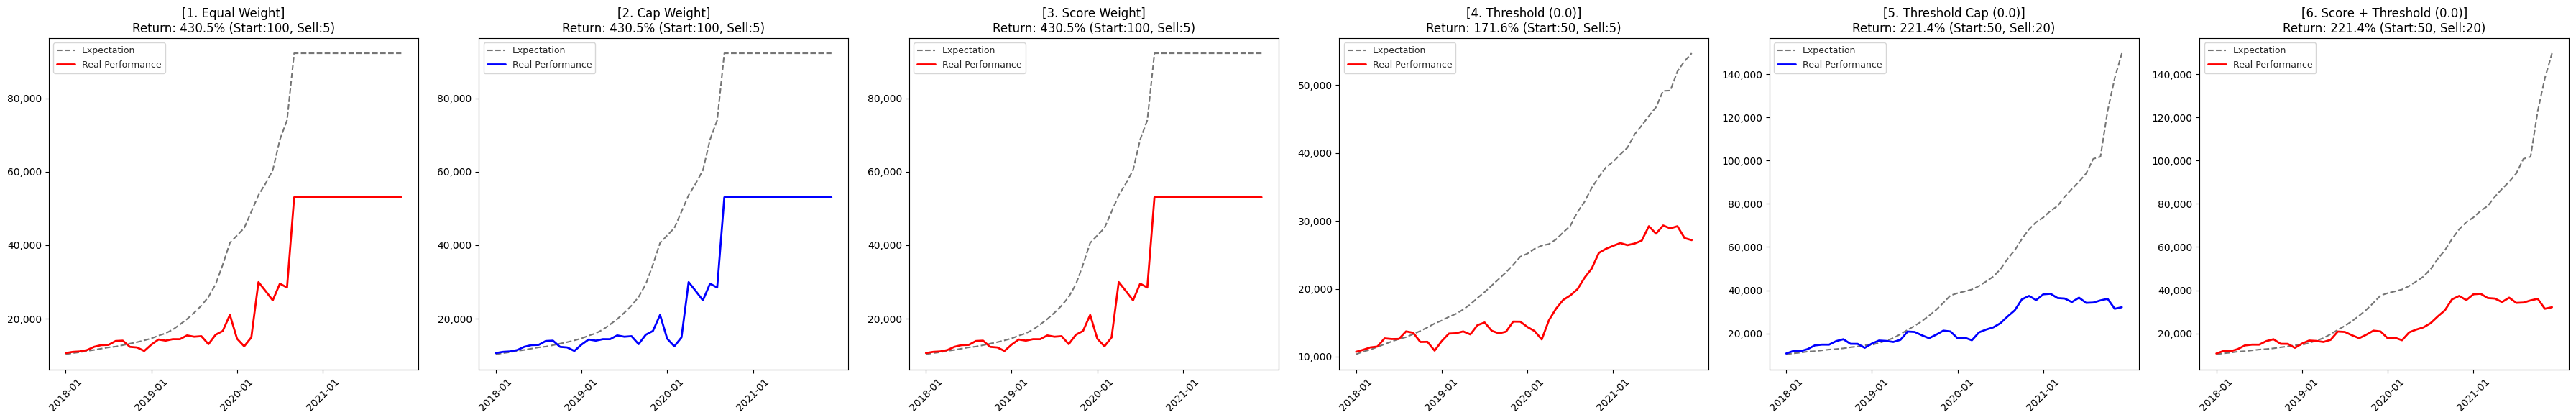


📌 [1. Equal Weight] 최적 결과: 수익률 430.53%
   (Init: 100개 / Sell: 5개 / Buy: 1개)

📌 [2. Cap Weight] 최적 결과: 수익률 430.53%
   (Init: 100개 / Sell: 5개 / Buy: 1개)

📌 [3. Score Weight] 최적 결과: 수익률 430.53%
   (Init: 100개 / Sell: 5개 / Buy: 1개)

📌 [4. Threshold (0.0)] 최적 결과: 수익률 171.58%
   (Init: 50개 / Sell: 5개 / Buy: 5개)

📌 [5. Threshold Cap (0.0)] 최적 결과: 수익률 221.35%
   (Init: 50개 / Sell: 20개 / Buy: 1개)

📌 [6. Score + Threshold (0.0)] 최적 결과: 수익률 221.35%
   (Init: 50개 / Sell: 20개 / Buy: 1개)


In [12]:
my_strategies = {
    '1. Equal Weight': Open_Market_Strategy_Equal,
    '2. Cap Weight': Open_Market_Strategy_Cap,
    '3. Score Weight': Open_Market_Strategy_Score,

    '4. Threshold (0.0)': lambda df, r, c, ns, nsl, nb, s: Open_Market_Strategy_Threshold(
        df, r, c, s, ns, nsl, nb, threshold=0.0
    ),
    '5. Threshold Cap (0.0)': lambda df, r, c, ns, nsl, nb, s: Open_Market_Strategy_Threshold_Cap(
        df, r, c, s, ns, nsl, nb, threshold=0.0
    ),
    '6. Score + Threshold (0.0)': lambda df, r, c, ns, nsl, nb, s: Open_Market_Strategy_Score_Threshold(
        df, r, c, s, ns, nsl, nb, threshold=0.0
    )
}

SEED_RANGE = [10000]
START_RANGE = [50, 100]
SELL_RANGE  = [1, 5, 10, 20]
BUY_RANGE   = [1, 5, 10, 20]

results = find_optimal_portfolio(
    df_all,
    my_strategies,
    SEED_RANGE, START_RANGE, SELL_RANGE, BUY_RANGE
)

## **단순 투자 전략과 비교**

### **비교 함수**

In [13]:
def calculate_buy_and_hold(df, target_tickers, initial_seed=100000, weight_type='equal'):
    """
    특정 종목 리스트를 시뮬레이션 시작일에 매수하여 끝까지 보유(Buy & Hold)하는 함수
    - weight_type='equal': 균등 비중 매수
    - weight_type='cap': 시가총액 비례 매수 (시작일 기준)
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique().tolist()
    start_ym = ym_list[0]

    # 시작 시점 데이터
    df_start = df[(df['yyyy_mm'] == start_ym) & (df['ticker'].isin(target_tickers))].copy()

    # 포트폴리오 초기 구성
    if weight_type == 'cap' and 'me' in df_start.columns:
        total_cap = df_start['me'].sum()
        df_start['alloc'] = (df_start['me'] / total_cap) * initial_seed
    else:
        # 균등 배분
        df_start['alloc'] = initial_seed / len(df_start)

    # 각 종목별 현재 평가금액 딕셔너리 {ticker: amount}
    portfolio = dict(zip(df_start['ticker'], df_start['alloc']))

    history_date = []
    history_seed = []
    current_total_value = initial_seed

    for ym in ym_list:
        # 현재 보유 중인 종목들의 이번 달 수익률 데이터 가져오기
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))]

        # 수익률 적용 (개별 종목 평가금액 갱신)
        # 매월 해당 종목의 수익률만큼 금액이 변동됨 (리밸런싱 없음 = Buy & Hold)
        if not df_curr.empty:
            for _, row in df_curr.iterrows():
                tik = row['ticker']
                ret = row['true_ret'] # 실제 수익률 기준
                if tik in portfolio:
                    portfolio[tik] = portfolio[tik] * (1 + ret)

        # 이번 달 총 평가금액 합산
        current_total_value = sum(portfolio.values())

        history_date.append(ym)
        history_seed.append(current_total_value)

    return history_date, history_seed

### **비교 결과**

벤치마크 시뮬레이션 중...


/tmp/ipython-input-1766144830.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


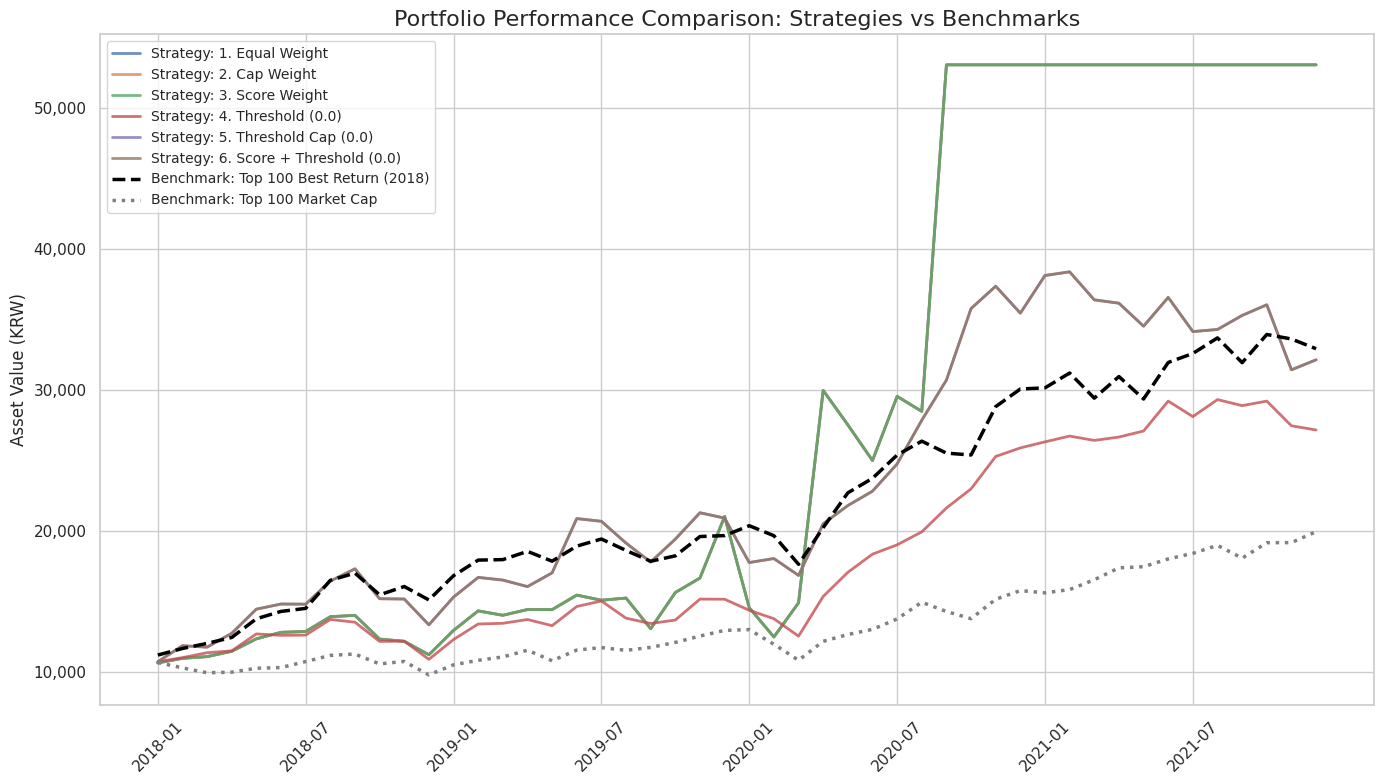


📌 [최종 성과 비교 요약]
1. Benchmark (2018 Best Return 100): 229.21%
2. Benchmark (Market Cap Top 100) : 99.48%
------------------------------------------------------------
Strategy [1. Equal Weight     ] : 430.53%
Strategy [2. Cap Weight       ] : 430.53%
Strategy [3. Score Weight     ] : 430.53%
Strategy [4. Threshold (0.0)  ] : 171.58%
Strategy [5. Threshold Cap (0.0)] : 221.35%
Strategy [6. Score + Threshold (0.0)] : 221.35%


In [14]:
# --- 1. 벤치마크 종목 선정 ---

# (1) 2018년 수익률 Top 100 (Perfect Foresight)
# 2018년 데이터만 필터링하여 종목별 연간 수익률 계산
df_2018 = df_all[df_all['date'].astype(str).str.startswith('2018')].copy()
df_2018['ret_plus_1'] = df_2018['true_ret'] + 1
# 누적 수익률 계산 (prod)
year_ret = df_2018.groupby('ticker')['ret_plus_1'].prod() - 1
top100_ret_tickers = year_ret.sort_values(ascending=False).head(100).index.tolist()

# (2) 2018년 1월 기준 시가총액 Top 100 (Market Cap)
start_date = df_all['date'].min() # 또는 '2018-01' 확인
df_start_cap = df_all[df_all['date'] == start_date].copy()
top100_cap_tickers = df_start_cap.sort_values(by='me', ascending=False).head(100)['ticker'].tolist()


# --- 2. 벤치마크 시뮬레이션 실행 ---
print("벤치마크 시뮬레이션 중...")
dates_bm1, seeds_bm1 = calculate_buy_and_hold(df_all, top100_ret_tickers, initial_seed=SEED_RANGE[0], weight_type='equal')
dates_bm2, seeds_bm2 = calculate_buy_and_hold(df_all, top100_cap_tickers, initial_seed=SEED_RANGE[0], weight_type='cap')


# --- 3. 통합 비교 그래프 그리기 ---
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# (A) 기존 최적 포트폴리오들 그리기
# results 변수에 저장된 최적 결과들을 순회
colors = sns.color_palette("husl", len(results))
for i, (name, data) in enumerate(results.items()):
    if data['ret'] == -999: continue
    plt.plot(data['dates'], data['seeds_real'], label=f"Strategy: {name}", linewidth=2, alpha=0.8)

# (B) 벤치마크 그리기
plt.plot(dates_bm1, seeds_bm1, label='Benchmark: Top 100 Best Return (2018)', color='black', linestyle='--', linewidth=2.5)
plt.plot(dates_bm2, seeds_bm2, label='Benchmark: Top 100 Market Cap', color='gray', linestyle=':', linewidth=2.5)

# 그래프 데코레이션
plt.title("Portfolio Performance Comparison: Strategies vs Benchmarks", fontsize=16)
plt.ylabel("Asset Value (KRW)", fontsize=12)
plt.legend(fontsize=10, loc='upper left')

# X축 날짜 포맷팅 (너무 빽빽하지 않게)
if len(dates_bm1) > 0:
    plt.xticks(range(0, len(dates_bm1), 6), [dates_bm1[i] for i in range(0, len(dates_bm1), 6)], rotation=45)

# Y축 콤마 포맷
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

# --- 4. 최종 수익률 요약 출력 ---
print("\n" + "="*60)
print("📌 [최종 성과 비교 요약]")
print("="*60)
final_bm1 = (seeds_bm1[-1] - SEED_RANGE[0]) / SEED_RANGE[0]
final_bm2 = (seeds_bm2[-1] - SEED_RANGE[0]) / SEED_RANGE[0]

print(f"1. Benchmark (2018 Best Return 100): {final_bm1*100:.2f}%")
print(f"2. Benchmark (Market Cap Top 100) : {final_bm2*100:.2f}%")
print("-" * 60)

for name, data in results.items():
    if data['ret'] == -999: continue
    print(f"Strategy [{name:20s}] : {data['ret']*100:.2f}%")
print("="*60)

## **최적 포트폴리오 분석**

### **함수**

In [15]:
def analyze_performance_drivers(df_all, results, target_strategy_name):
    """
    특정 전략의 승리 요인(대박 종목, 적중률, 최고의 순간)을 분석하는 함수
    """
    if target_strategy_name not in results:
        print(f"Error: '{target_strategy_name}' 전략의 결과가 없습니다.")
        return

    data = results[target_strategy_name]
    log_df = data['log']

    # 1. 2018년 전체 종목의 실제 연간 수익률 계산 (누가 진짜 대박이었나?)
    df_2018 = df_all[df_all['date'].astype(str).str.startswith('2018')].copy()
    df_2018['ret_plus_1'] = df_2018['true_ret'] + 1
    # 종목별 연간 누적 수익률
    stock_yearly_ret = df_2018.groupby('ticker')['ret_plus_1'].prod() - 1

    # 2. 내 전략이 매수한 종목들 추출
    bought_tickers = log_df[log_df['action'].isin(['Buy', 'Initial Buy'])]['ticker'].unique()

    # 3. 매수한 종목들의 성적표 매칭
    my_picks_df = pd.DataFrame({'ticker': bought_tickers})
    my_picks_df = my_picks_df.merge(stock_yearly_ret.rename('actual_year_ret'), on='ticker', how='left')

    # 분석 1: 신의 한 수 (내가 산 것 중 가장 수익률이 높았던 종목 Top 10)
    top_contributors = my_picks_df.sort_values(by='actual_year_ret', ascending=False).head(10)

    # 분석 2: 적중률 (산 종목 중 +수익인 비율)
    total_bought = len(my_picks_df)
    winners = len(my_picks_df[my_picks_df['actual_year_ret'] > 0])
    hit_rate = (winners / total_bought) * 100 if total_bought > 0 else 0

    # 분석 3: 최고의 한 달 (월별 수익률 역산)
    seeds = data['seeds_real']
    dates = data['dates']
    monthly_rets = []

    # 시드 변화로 월별 수익률 계산
    prev_seed = seeds[0] # 초기 자금 아님. 첫 달 정산 후 자금임.
    # 정확한 계산을 위해 초기 자금(SEED_RANGE[0])을 맨 앞에 추가
    full_seeds = [SEED_RANGE[0]] + seeds

    for i in range(1, len(full_seeds)):
        ret = (full_seeds[i] - full_seeds[i-1]) / full_seeds[i-1]
        monthly_rets.append({'date': dates[i-1], 'monthly_return': ret})

    df_monthly = pd.DataFrame(monthly_rets)
    best_months = df_monthly.sort_values(by='monthly_return', ascending=False).head(3)

    # --- 리포트 출력 ---
    print("\n" + "="*60)
    print(f"🔎 전략 심층 분석: [{target_strategy_name}]")
    print("="*60)

    print(f"1. 종목 선정 적중률 (Hit Rate)")
    print(f"   - 총 매수 종목 수 : {total_bought}개")
    print(f"   - 실제 상승 종목  : {winners}개")
    print(f"   - 적중률          : {hit_rate:.2f}%")
    print("-" * 60)

    print(f"2. '신의 한 수' Top 10 (포트폴리오에 담았던 대박 종목들)")
    print(f"   (이 종목들을 보유했기 때문에 수익이 났을 가능성이 큽니다)")
    print("-" * 60)
    print(f"{'Ticker':<10} | {'2018 실제 수익률':<15}")
    for _, row in top_contributors.iterrows():
        print(f"{row['ticker']:<10} | {row['actual_year_ret']*100:6.2f}%")
    print("-" * 60)

    print(f"3. 결정적 순간 (수익이 폭발한 최고의 달)")
    for _, row in best_months.iterrows():
        print(f"   - {row['date']} : +{row['monthly_return']*100:.2f}%")
    print("="*60)

### **결과**

In [16]:
analyze_performance_drivers(df_all, results, '1. Equal Weight')


🔎 전략 심층 분석: [1. Equal Weight]
1. 종목 선정 적중률 (Hit Rate)
   - 총 매수 종목 수 : 112개
   - 실제 상승 종목  : 52개
   - 적중률          : 46.43%
------------------------------------------------------------
2. '신의 한 수' Top 10 (포트폴리오에 담았던 대박 종목들)
   (이 종목들을 보유했기 때문에 수익이 났을 가능성이 큽니다)
------------------------------------------------------------
Ticker     | 2018 실제 수익률    
TWLO       | 278.39%
OKTA       | 149.12%
ETSY       | 132.62%
COUP       | 101.35%
SRPT       |  96.14%
CHGG       |  74.14%
RNG        |  70.33%
AAXN       |  65.09%
VEEV       |  61.58%
PLNT       |  54.84%
------------------------------------------------------------
3. 결정적 순간 (수익이 폭발한 최고의 달)
   - 2020-04 : +101.05%
   - 2020-09 : +86.28%
   - 2019-12 : +26.20%


In [17]:
analyze_performance_drivers(df_all, results, '2. Cap Weight')


🔎 전략 심층 분석: [2. Cap Weight]
1. 종목 선정 적중률 (Hit Rate)
   - 총 매수 종목 수 : 112개
   - 실제 상승 종목  : 52개
   - 적중률          : 46.43%
------------------------------------------------------------
2. '신의 한 수' Top 10 (포트폴리오에 담았던 대박 종목들)
   (이 종목들을 보유했기 때문에 수익이 났을 가능성이 큽니다)
------------------------------------------------------------
Ticker     | 2018 실제 수익률    
TWLO       | 278.39%
OKTA       | 149.12%
ETSY       | 132.62%
COUP       | 101.35%
SRPT       |  96.14%
CHGG       |  74.14%
RNG        |  70.33%
AAXN       |  65.09%
VEEV       |  61.58%
PLNT       |  54.84%
------------------------------------------------------------
3. 결정적 순간 (수익이 폭발한 최고의 달)
   - 2020-04 : +101.05%
   - 2020-09 : +86.28%
   - 2019-12 : +26.20%


In [18]:
analyze_performance_drivers(df_all, results, '3. Score Weight')


🔎 전략 심층 분석: [3. Score Weight]
1. 종목 선정 적중률 (Hit Rate)
   - 총 매수 종목 수 : 112개
   - 실제 상승 종목  : 52개
   - 적중률          : 46.43%
------------------------------------------------------------
2. '신의 한 수' Top 10 (포트폴리오에 담았던 대박 종목들)
   (이 종목들을 보유했기 때문에 수익이 났을 가능성이 큽니다)
------------------------------------------------------------
Ticker     | 2018 실제 수익률    
TWLO       | 278.39%
OKTA       | 149.12%
ETSY       | 132.62%
COUP       | 101.35%
SRPT       |  96.14%
CHGG       |  74.14%
RNG        |  70.33%
AAXN       |  65.09%
VEEV       |  61.58%
PLNT       |  54.84%
------------------------------------------------------------
3. 결정적 순간 (수익이 폭발한 최고의 달)
   - 2020-04 : +101.05%
   - 2020-09 : +86.28%
   - 2019-12 : +26.20%


### **실제 수익률 기준Top10 종목 주식 그래프**

In [19]:
!pip install yfinance

In [20]:
import yfinance as yf

In [21]:
def analyze_top_contributors_price_trajectory(df_all, results, target_strategy_name):
    """
    특정 전략이 매수한 종목 중, 가장 높은 총 기간 수익률을 기록한 Top 10 종목의
    주가 궤적을 Yahoo Finance 데이터를 이용하여 시각화합니다.

    df_all: 전체 시뮬레이션 데이터 (df_sim)
    results: 실행 결과 딕셔너리
    TARGET_STRATEGY: 분석할 전략 이름 ('Smart Beta', 'Equal Weight' 등)
    """

    if target_strategy_name not in results:
        print(f"Error: '{target_strategy_name}' 전략의 결과가 없습니다.")
        return

    # ensure 'date' column is datetime
    df_all['date'] = pd.to_datetime(df_all['date'])

    # ---------------------------------------------------------
    # [Step 1] Top 10 선정 (전체 시뮬레이션 기간 수익률 기준)
    # ---------------------------------------------------------
    log_df = results[target_strategy_name]['log']

    # 전략이 매수한 모든 고유 티커 추출
    bought_tickers = log_df[log_df['action'].isin(['Buy', 'Initial Buy'])]['ticker'].unique()

    # 전체 기간 동안의 종목별 실제 수익률 계산 (df_all == df_sim)
    df_all['ret_plus_1'] = df_all['true_ret'] + 1
    # 종목별 누적 수익률 (전체 기간)
    stock_total_ret = df_all.groupby('ticker')['ret_plus_1'].prod() - 1

    # 매수한 종목들의 성적표 매칭 및 Top 10 선정
    my_picks_ret = stock_total_ret[stock_total_ret.index.isin(bought_tickers)]
    my_top_10 = my_picks_ret.sort_values(ascending=False).head(10).index.tolist()

    print(f"🎯 전략 [{target_strategy_name}]의 Top 10 컨트리뷰터 선정 완료.")

    # ---------------------------------------------------------
    # [Step 2] 티커 보정 및 야후 파이낸스 다운로드 준비
    # ---------------------------------------------------------
    # 야후 파이낸스용 티커 보정 (예: AAXN -> AXON)
    my_top_10_yf = [t.replace('AAXN', 'AXON') for t in my_top_10]

    # 시작일과 종료일 설정 (df_all의 기간과 일치시키기 위해)
    start_date = df_all['date'].min().strftime('%Y-%m-%d')
    end_date = df_all['date'].max().strftime('%Y-%m-%d')

    print(f"📌 최종 주가 추적 리스트: {my_top_10_yf} (기간: {start_date} ~ {end_date})")

    # Yahoo Finance 다운로드
    try:
        # auto_adjust=True: 배당/분할 자동 반영, Close 컬럼만 사용
        stock_data = yf.download(my_top_10_yf, start=start_date, end=end_date, auto_adjust=True)['Close']
    except Exception as e:
        print(f"❌ Yahoo Finance 다운로드 실패: {e}. 라이브러리 설치 및 네트워크를 확인하세요.")
        return

    # ---------------------------------------------------------
    # [Step 3] 그래프 그리기 (지수화 및 플롯)
    # ---------------------------------------------------------

    # 지수화 (Start Date = 100)
    normalized_data = stock_data.copy()

    plt.figure(figsize=(14, 8))
    sns.set_theme(style="whitegrid")

    for ticker_yf in my_top_10_yf:
        if ticker_yf in normalized_data.columns:
            # 원본 티커 이름 복구 (수익률 매칭용)
            original_ticker = ticker_yf.replace('AXON', 'AAXN')

            # 정규화 (첫 유효값 기준 100)
            first_valid = normalized_data[ticker_yf].first_valid_index()
            if first_valid is not None:
                base_value = normalized_data.loc[first_valid, ticker_yf]
                normalized_data[ticker_yf] = (normalized_data[ticker_yf] / base_value) * 100

                # 최종 수익률 (전체 시뮬레이션 기간 기준)
                final_ret = stock_total_ret.get(original_ticker, 0) * 100

                plt.plot(normalized_data.index, normalized_data[ticker_yf],
                         label=f"{original_ticker} (Total Ret: +{final_ret:.0f}%)")

    plt.title(f"My Portfolio's Top Contributors ({target_strategy_name}) - Price Trajectory (Normalized)", fontsize=16)
    plt.ylabel("Price Index (Start=100)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title="Ticker (Total Return)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

🎯 전략 [1. Equal Weight]의 Top 10 컨트리뷰터 선정 완료.
📌 최종 주가 추적 리스트: ['TWLO', 'ETSY', 'OKTA', 'HUBS', 'ROKU', 'AXON', 'IMMU', 'COUP', 'PCTY', 'ENTG'] (기간: 2018-01-31 ~ 2021-12-31)


[*********************100%***********************]  10 of 10 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['COUP', 'IMMU']: YFTzMissingError('possibly delisted; no timezone found')


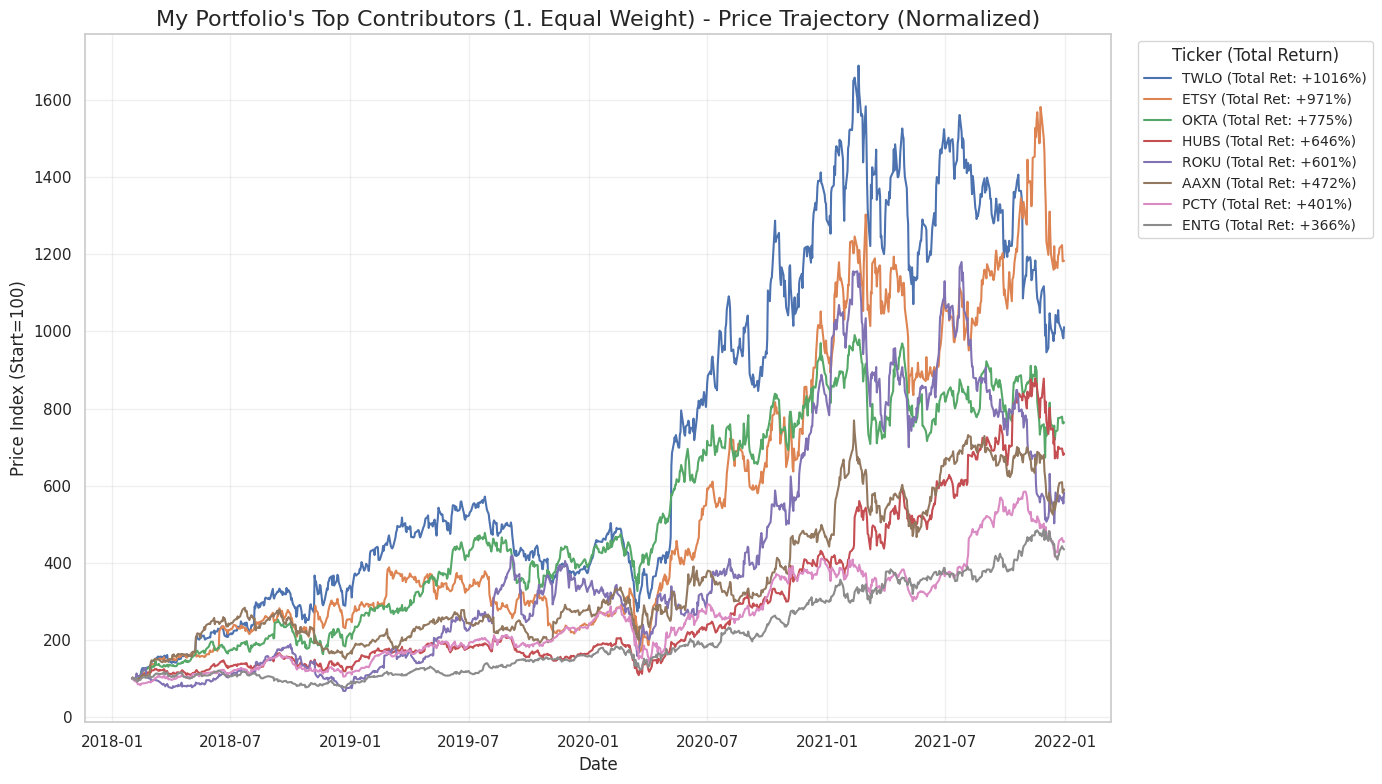

In [22]:
analyze_top_contributors_price_trajectory(df_all, results, '1. Equal Weight')

### **기여도 Top10 종목 주식 그래프**

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

def get_trc_top10_my_strategy(df, rank_col, calc_col, mode='equal', n_start=50, n_sell=10, n_buy=10, initial_seed=1000000, threshold=None):
    """
    threshold=None : 임계값 없음 (무조건 하위 n_sell개 매도) -> 전략 1, 2, 3 해당
    threshold=0.0  : 임계값 있음 (하위 n_sell개 중 점수가 0 미만인 것만 매도) -> 전략 4, 5, 6 해당
    """
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['yyyy_mm'] = df['date'].dt.strftime('%Y-%m')
    df = df.sort_values('date')

    ym_list = df['yyyy_mm'].unique().tolist()
    start_ym = ym_list[0]

    trc_tracker = {} # 기여도 추적

    # --- 초기 세팅 ---
    df_start = df[df['yyyy_mm'] == start_ym]
    top_n_tickers = df_start.sort_values(by=rank_col, ascending=False).head(n_start)['ticker'].tolist()

    portfolio = {ticker: 1.0 for ticker in top_n_tickers}
    current_seed = initial_seed

    for ym in ym_list:
        my_tickers = list(portfolio.keys())
        df_curr = df[(df['yyyy_mm'] == ym) & (df['ticker'].isin(my_tickers))].copy()

        if df_curr.empty: continue

        # 1. TRC 계산
        total_units = sum(portfolio.values())
        df_curr['units'] = df_curr['ticker'].map(portfolio)
        df_curr['weight'] = df_curr['units'] / total_units
        df_curr['contribution'] = df_curr['weight'] * df_curr[calc_col] * current_seed # 기여금액($)

        for idx, row in df_curr.iterrows():
            trc_tracker[row['ticker']] = trc_tracker.get(row['ticker'], 0) + row['contribution']

        # 자산 업데이트
        port_ret = (df_curr[calc_col] * df_curr['weight']).sum()
        current_seed = current_seed * (1 + port_ret)

        # 2. 리밸런싱 (매도 로직 분기)
        my_rank = df_curr.sort_values(by=rank_col, ascending=True)
        candidates_df = my_rank.head(n_sell)

        # [수정됨] threshold 값 유무에 따른 매도 대상 선정
        if threshold is None:
            # 임계값 없음: 하위 n개 무조건 매도 (전략 1, 2, 3)
            real_sell_tickers = candidates_df['ticker'].tolist()
        else:
            # 임계값 있음: 하위 n개 중 점수가 threshold 미만인 것만 매도 (전략 4, 5, 6)
            real_sell_tickers = candidates_df[candidates_df[rank_col] < threshold]['ticker'].tolist()

        freed_points = 0.0
        for ticker in real_sell_tickers:
            if ticker in portfolio:
                freed_points += portfolio[ticker]
                del portfolio[ticker]

        # 방어형(임계값) 전략의 경우 매도를 안 할 수도 있음 -> 이 경우 희석 효과 반영을 위해 가상의 자금 확보 가정
        if freed_points == 0: freed_points = float(n_sell)

        # 3. 매수 (mode에 따른 분기)
        df_market = df[df['yyyy_mm'] == ym]

        if mode == 'equal':
            best_candidates = df_market.sort_values(by=rank_col, ascending=False).head(n_buy)['ticker'].tolist()
            # 전략 4(Threshold)의 경우 원본 코드에서 1.0씩 더하는 로직 사용 -> 여기서도 유사하게 처리
            # 하지만 비교를 위해 'freed_points / n_buy'로 통일해도 무방함 (여기선 통일성 유지)
            points_per_buy = freed_points / n_buy
            for ticker in best_candidates:
                portfolio[ticker] = portfolio.get(ticker, 0) + points_per_buy

        elif mode == 'cap':
            top_n_df = df_market.sort_values(by=rank_col, ascending=False).head(n_buy).copy()
            total_me = top_n_df['me'].sum()
            top_n_df['alloc_points'] = (top_n_df['me'] / total_me) * freed_points
            for _, row in top_n_df.iterrows():
                portfolio[row['ticker']] = portfolio.get(row['ticker'], 0) + row['alloc_points']

        elif mode == 'score':
            top_n_df = df_market.sort_values(by=rank_col, ascending=False).head(n_buy).copy()
            scores = top_n_df[rank_col].clip(lower=0)
            total_score = scores.sum()
            if total_score > 0:
                top_n_df['alloc_points'] = (scores / total_score) * freed_points
            else:
                top_n_df['alloc_points'] = freed_points / n_buy
            for _, row in top_n_df.iterrows():
                portfolio[row['ticker']] = portfolio.get(row['ticker'], 0) + row['alloc_points']

    sorted_trc = sorted(trc_tracker.items(), key=lambda x: x[1], reverse=True)
    top10_tickers = [x[0] for x in sorted_trc[:10]]

    return top10_tickers, sorted_trc[:10]

📌 [equal] 전략의 실제 수익 기여(TRC) Top 10 종목
1. AMC : +4,902 $ 기여
2. IMMU : +3,476 $ 기여
3. NVAX : +3,091 $ 기여
4. TSLA : +1,591 $ 기여
5. MRTX : +1,509 $ 기여
6. ROKU : +1,246 $ 기여
7. EQT : +1,133 $ 기여
8. MDB : +671 $ 기여
9. TNDM : +589 $ 기여
10. DXC : +559 $ 기여


[*********************100%***********************]  10 of 10 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['MRTX', 'IMMU']: YFTzMissingError('possibly delisted; no timezone found')


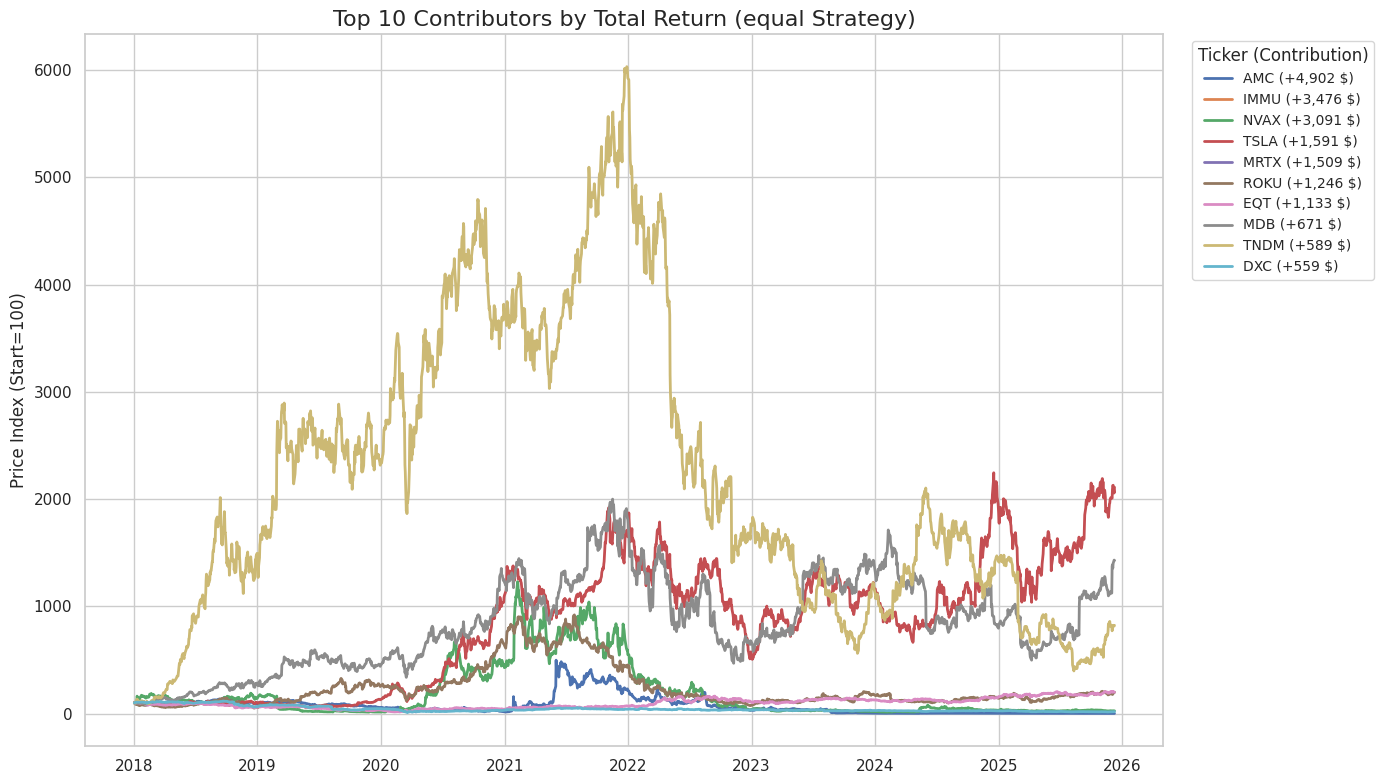

In [25]:
# --------------------------------------------------------------------------------
# [실행 및 시각화]
# --------------------------------------------------------------------------------

# 1. 파라미터 설정 (최적화 결과나 원하시는 설정 사용)
TARGET_MODE = 'equal'  # 'equal', 'cap', 'score' 중 선택
MY_SEED = 10000        # 시뮬레이션 초기 자금
N_START = 50
N_SELL = 10
N_BUY = 10

# 2. TRC Top 10 추출
# 주의: 기여도 계산이므로 calc_col은 'true_ret'(실제 수익률)을 넣어야 정확합니다.
trc_top10, trc_vals = get_trc_top10_my_strategy(
    df_all, 'pred_ret', 'true_ret',
    mode='equal', threshold=None,  # <--- 여기 확인
    n_start=50, n_sell=10, n_buy=10, initial_seed=10000
)

print(f"📌 [{TARGET_MODE}] 전략의 실제 수익 기여(TRC) Top 10 종목")
for rank, (ticker, money) in enumerate(trc_vals, 1):
    print(f"{rank}. {ticker} : +{money:,.0f} $ 기여")

# 3. 그래프 그리기 (Yahoo Finance 데이터 연동)
# 티커 보정
trc_top10_tickers_fixed = ['AXON' if x == 'AAXN' else x for x in trc_top10]
# COUP는 Yahoo Finance에서 검색이 안 되므로 제거합니다.
if 'COUP' in trc_top10_tickers_fixed: trc_top10_tickers_fixed.remove('COUP')

# 주가 다운로드
stock_data = yf.download(trc_top10_tickers_fixed, start='2018-01-01', end='2025-12-31', auto_adjust=True)['Close']

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 지수화 (Start=100)
normalized_data = stock_data.copy()
for col in normalized_data.columns:
    first_valid = normalized_data[col].first_valid_index()
    if first_valid is not None:
        base_value = normalized_data.loc[first_valid, col]
        if base_value > 0:
            normalized_data[col] = (normalized_data[col] / base_value) * 100

# 플롯
for ticker in trc_top10_tickers_fixed:
    if ticker in normalized_data.columns:
        # 원래 티커명 복원 (기여금액 표시용)
        orig_ticker = 'AAXN' if ticker == 'AXON' else ticker

        # 해당 종목의 기여금액 찾기
        contribution = next((amt for t, amt in trc_vals if t == orig_ticker), 0)

        plt.plot(normalized_data.index, normalized_data[ticker],
                 label=f"{ticker} (+{contribution:,.0f} $)", linewidth=2)

plt.title(f"Top 10 Contributors by Total Return ({TARGET_MODE} Strategy)", fontsize=16)
plt.ylabel("Price Index (Start=100)", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title="Ticker (Contribution)")
plt.tight_layout()
plt.show()